In [1]:
import sqlite3
import pandas as pd
from datetime import datetime, date
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Définir l'affichage de toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
conn = sqlite3.connect(r'C:\Document\Python\Projet\Projet_3\Top_gun\bdd_sql\top_gun_data_1.db')

In [3]:
df_degra = pd.read_sql_query("SELECT * FROM degradations", conn)
df_aero = pd.read_sql_query("SELECT * FROM aeronefs", conn)
df_compo = pd.read_sql_query("SELECT * FROM composants", conn)
df_logs_vols = pd.read_sql_query("SELECT * FROM logs_vols", conn)

### DF Aéro

In [4]:
df_aero.head(2)

,ref_aero,type_model,debut_service,last_maint,en_maintenance,end_maint
0,E170_6353,E170,2000-03-17,2024-03-27,0,1970-01-01
1,B767_2803,B767,2020-12-03,2024-06-01,0,1970-01-01


In [5]:
df_aero.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ref_aero        230 non-null    object
 1   type_model      230 non-null    object
 2   debut_service   230 non-null    object
 3   last_maint      230 non-null    object
 4   en_maintenance  230 non-null    int64 
 5   end_maint       230 non-null    object
dtypes: int64(1), object(5)
memory usage: 10.9+ KB


### Logs_vols

In [6]:
df_logs_vols.head(2)

,ref_vol,aero_linked,jour_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²
0,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116
1,V02564879,B747_3165,2024-06-02,5.1,0,0.9,950.6,4.558


In [7]:
first_service = {}
for index, row in df_aero.iterrows():
    first_service[row['ref_aero']] = row['debut_service']

In [8]:
df_logs_vols['first_service_date'] = df_logs_vols['aero_linked'].map(first_service)

In [9]:
df_logs_vols['first_service_date'] = pd.to_datetime(df_logs_vols['first_service_date'])
df_logs_vols['age'] = pd.to_datetime(date.today()) - df_logs_vols['first_service_date']

In [10]:
df_logs_vols['age'] = df_logs_vols['age'].astype('int64')
ns_per_year = 365.25 * 24 * 60 * 60 * 10**9
df_logs_vols['age'] = round(df_logs_vols['age'].astype('int64') / ns_per_year, 2)

In [11]:
""" fonction pour cumuler les heure de vols de chaque aeronef """

cumulative_hour_in_air = {}
cumulative_fly_hours = []

for _, row in df_logs_vols.iterrows():
    id_aero = row['aero_linked']
    time_en_air = row['time_en_air']
    
    if id_aero in cumulative_hour_in_air:
        cumulative_hour_in_air[id_aero] += time_en_air
    else:
        cumulative_hour_in_air[id_aero] = time_en_air
    
    cumulative_fly_hours.append(cumulative_hour_in_air[id_aero])

# Ajouter la nouvelle colonne au DataFrame
df_logs_vols['cumulative_hours'] = cumulative_fly_hours

In [12]:
df_logs_vols['jour_vol'] = pd.to_datetime(df_logs_vols['jour_vol'], format='%Y-%m-%d')

In [13]:
# creation d'un dictionnaire pour les reférences des composants
name_compo = {
    0: 'REAE', 1: 'REAE', 2: 'SYSE', 3: 'ORDE', 4: 'AUTE', 5: 'SYSE', 6: 'RADE', 7: 'SYSE',
    8: 'SYSE', 9: 'SYSE', 10: 'SYSE', 11: 'UNIE', 12: 'SYSE', 13: 'SYSE', 14: 'SYSE',
    15: 'SYSE', 16: 'GENE', 17: 'TRAE', 18: 'TRAE', 19: 'SYSE', 20: 'AILE', 21: 'EMPE',
    22: 'FLAE', 23: 'SPOE', 24: 'FREE', 25: 'SYSE', 26: 'GOUE', 27: 'SYSE', 28: 'SYSE',
    29: 'SYSE', 30: 'ECLE', 31: 'SIEE', 32: 'SIEE', 33: 'SYSE', 34: 'SYSE', 35: 'TOIE',
    36: 'SYSE', 37: 'DETE', 38: 'ECLE', 39: 'PORE', 40: 'SYSE', 41: 'PORE', 42: 'HUBE',
    43: 'ECLE', 44: 'SYSE'
}

In [14]:
# Répéter chaque ligne 45 fois
df_vols = pd.DataFrame(np.repeat(df_logs_vols.values, 45, axis=0), columns=df_logs_vols.columns)

# Assigner id_desc de 0 à 44 pour chaque avion
df_vols['id_desc'] = np.tile(np.arange(45), len(df_logs_vols))

# Convertir id_desc en entier
df_vols['id_desc'] = df_vols['id_desc'].astype(int)

# Réinitialiser l'index du DataFrame
df_vols.reset_index(drop=True, inplace=True)

# Afficher le DataFrame étendu avec id_desc attribué
df_vols

,ref_vol,aero_linked,jour_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,first_service_date,age,cumulative_hours,id_desc
0,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,0
1,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,1
2,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,2
3,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,3
4,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
136795,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,40
136796,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,41
136797,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,42
136798,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,43


In [725]:
'''
df_vols.drop(['time_en_air', 'temp en °C', 'pressure en hPa', 'vibrations en m/s²', 'ref_vol'], axis=1, inplace=True)
'''

"\ndf_vols.drop(['time_en_air', 'temp en °C', 'pressure en hPa', 'vibrations en m/s²', 'ref_vol'], axis=1, inplace=True)\n"

In [15]:
df_vols['id_vol'] = df_vols['aero_linked'] + ' / ' + df_vols['jour_vol'].astype(str)
df_vols

,ref_vol,aero_linked,jour_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,first_service_date,age,cumulative_hours,id_desc,id_vol
0,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,0,B767_4924 / 2024-06-02
1,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,1,B767_4924 / 2024-06-02
2,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,2,B767_4924 / 2024-06-02
3,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,3,B767_4924 / 2024-06-02
4,V07679725,B767_4924,2024-06-02,7.0,0,-5.7,930.6,3.116,2005-07-29,18.93,7.0,4,B767_4924 / 2024-06-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
136795,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,40,CRJ900_1943 / 2024-07-02
136796,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,41,CRJ900_1943 / 2024-07-02
136797,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,42,CRJ900_1943 / 2024-07-02
136798,V02755264,CRJ900_1943,2024-07-02,1.6,0,10.5,914.6,2.687,2011-03-30,13.26,71.9,43,CRJ900_1943 / 2024-07-02


In [16]:
day2 = df_vols[df_vols['aero_linked'] == 'B767_4924']
day2['jour_vol'].unique()

<DatetimeArray>
['2024-06-02 00:00:00', '2024-06-03 00:00:00', '2024-06-05 00:00:00',
 '2024-06-10 00:00:00', '2024-06-12 00:00:00', '2024-06-16 00:00:00',
 '2024-06-18 00:00:00', '2024-06-20 00:00:00', '2024-06-22 00:00:00',
 '2024-06-23 00:00:00', '2024-06-25 00:00:00', '2024-07-02 00:00:00']
Length: 12, dtype: datetime64[ns]

### DF COMPOSANTS

In [17]:
df_compo['id_desc'] = df_compo['ref_compo'].str.split('-').str[-1]
df_compo['measure_day'] = pd.to_datetime('2024-05-31')

In [18]:
df_compo.head(2)

,ref_compo,categorie,aero,desc,lifespan,taux_usure_actuel,cout,id_desc,measure_day
0,REAE170-E170_6353-0,2,E170_6353,Réacteur gauche,13045.0,53.308375,15552.0,0,2024-05-31
1,REAE170-E170_6353-1,2,E170_6353,Réacteur droit,13626.0,50.111950,17559.0,1,2024-05-31


#### Dictionnaire composants

In [19]:
# Création d'un dictionnaore composants

# Suppression des doublons
df_compo_unique = df_compo.drop_duplicates('id_desc')

# Conversion en dictionnaire
compo_dict = df_compo_unique.set_index('id_desc')[['desc', 'lifespan', 'categorie', 'cout']].to_dict(orient='index')

# Afficher le dictionnaire
print(compo_dict)

{'0': {'desc': 'Réacteur gauche', 'lifespan': 13045.0, 'categorie': 2, 'cout': 15552.0}, '1': {'desc': 'Réacteur droit', 'lifespan': 13626.0, 'categorie': 2, 'cout': 17559.0}, '2': {'desc': 'Système de navigation', 'lifespan': 10541.0, 'categorie': 2, 'cout': 16514.0}, '3': {'desc': 'Ordinateur de vol', 'lifespan': 10441.0, 'categorie': 2, 'cout': 16047.0}, '4': {'desc': 'Autopilote', 'lifespan': 14847.0, 'categorie': 2, 'cout': 19362.0}, '5': {'desc': 'Système de contrôle de vol', 'lifespan': 12580.0, 'categorie': 2, 'cout': 19492.0}, '6': {'desc': 'Radar météorologique', 'lifespan': 11923.0, 'categorie': 2, 'cout': 17567.0}, '7': {'desc': 'Système de communication radio', 'lifespan': 10370.0, 'categorie': 2, 'cout': 19214.0}, '8': {'desc': 'Système de gestion de carburant', 'lifespan': 13219.0, 'categorie': 2, 'cout': 18351.0}, '9': {'desc': "Système d'alerte de proximité au sol (GPWS)", 'lifespan': 10423.0, 'categorie': 2, 'cout': 18680.0}, '10': {'desc': 'Système de commande des ga

In [20]:
# Suppression des colonnes dans df_compo
df_compo.drop(['desc', 'lifespan', 'categorie', 'cout'], axis=1, inplace=True)

In [21]:
# Renommer les colonnes
df_compo.columns = ['ref_compo', 'aero', 'usure', 'id_desc', 'measure_day']

### DF DEGRADATIONS

In [22]:
# creation colonne id_desc qui récupére le nombre après le tiret dans compo_concerned
df_degra['id_desc'] = df_degra['compo_concerned'].str.split('-').str[-1]

In [23]:
# Measure day au format date
df_degra['measure_day'] = pd.to_datetime(df_degra['measure_day'], format='%Y-%m-%d')

In [24]:
df_degra.head(2)

,ref_deg,linked_aero,compo_concerned,usure_nouvelle,measure_day,need_replacement,id_desc
0,D003661,E170_6353,REAE170-E170_6353-0,53.0,2024-06-01,0,0
1,D009402,E170_6353,REAE170-E170_6353-1,50.0,2024-06-01,0,1


In [25]:
# suppression colonnes dans df_degra
df_degra.drop(['ref_deg', 'need_replacement'], axis=1, inplace=True)

In [26]:
# on renomme les colonnes
df_degra.columns = ['aero', 'ref_compo', 'usure', 'measure_day', 'id_desc']

### CONCAT

In [27]:
# Concat df_compo et df_degra
df_compo_degra = pd.concat([df_compo, df_degra], ignore_index=True)

In [28]:
df_compo_degra

,ref_compo,aero,usure,id_desc,measure_day
0,REAE170-E170_6353-0,E170_6353,53.308375,0,2024-05-31
1,REAE170-E170_6353-1,E170_6353,50.111950,1,2024-05-31
2,SYSE170-E170_6353-2,E170_6353,16.730575,2,2024-05-31
3,ORDE170-E170_6353-3,E170_6353,6.653075,3,2024-05-31
4,AUTE170-E170_6353-4,E170_6353,42.033525,4,2024-05-31
...,...,...,...,...,...
153040,SYSCRJ700-CRJ700_2988-40,CRJ700_2988,63.000000,40,2024-07-02
153041,PORCRJ700-CRJ700_2988-41,CRJ700_2988,26.000000,41,2024-07-02
153042,HUBCRJ700-CRJ700_2988-42,CRJ700_2988,84.000000,42,2024-07-02
153043,ECLCRJ700-CRJ700_2988-43,CRJ700_2988,44.000000,43,2024-07-02


In [740]:
'''
df_compo_degra['desc'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['desc'] if x in compo_dict else None)
df_compo_degra['lifespan'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['lifespan'] if x in compo_dict else None)
df_compo_degra['categorie'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['categorie'] if x in compo_dict else None)
df_compo_degra['cout'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['cout'] if x in compo_dict else None)
'''

"\ndf_compo_degra['desc'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['desc'] if x in compo_dict else None)\ndf_compo_degra['lifespan'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['lifespan'] if x in compo_dict else None)\ndf_compo_degra['categorie'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['categorie'] if x in compo_dict else None)\ndf_compo_degra['cout'] = df_compo_degra['id_desc'].map(lambda x: compo_dict[x]['cout'] if x in compo_dict else None)\n"

In [29]:
day = df_compo_degra[df_compo_degra['aero'] == 'B767_4924']
day['measure_day'].unique()

<DatetimeArray>
['2024-05-31 00:00:00', '2024-06-02 00:00:00', '2024-06-03 00:00:00',
 '2024-06-05 00:00:00', '2024-06-10 00:00:00', '2024-06-12 00:00:00',
 '2024-06-16 00:00:00', '2024-06-18 00:00:00', '2024-06-20 00:00:00',
 '2024-06-22 00:00:00', '2024-06-23 00:00:00', '2024-06-25 00:00:00',
 '2024-07-02 00:00:00']
Length: 13, dtype: datetime64[ns]

In [30]:
# Creation d'une colonne id_vol pour merge logs_vols
df_compo_degra['id_vol'] = df_compo_degra['aero'] + ' / ' + df_compo_degra['measure_day'].astype(str)
df_compo_degra

,ref_compo,aero,usure,id_desc,measure_day,id_vol
0,REAE170-E170_6353-0,E170_6353,53.308375,0,2024-05-31,E170_6353 / 2024-05-31
1,REAE170-E170_6353-1,E170_6353,50.111950,1,2024-05-31,E170_6353 / 2024-05-31
2,SYSE170-E170_6353-2,E170_6353,16.730575,2,2024-05-31,E170_6353 / 2024-05-31
3,ORDE170-E170_6353-3,E170_6353,6.653075,3,2024-05-31,E170_6353 / 2024-05-31
4,AUTE170-E170_6353-4,E170_6353,42.033525,4,2024-05-31,E170_6353 / 2024-05-31
...,...,...,...,...,...,...
153040,SYSCRJ700-CRJ700_2988-40,CRJ700_2988,63.000000,40,2024-07-02,CRJ700_2988 / 2024-07-02
153041,PORCRJ700-CRJ700_2988-41,CRJ700_2988,26.000000,41,2024-07-02,CRJ700_2988 / 2024-07-02
153042,HUBCRJ700-CRJ700_2988-42,CRJ700_2988,84.000000,42,2024-07-02,CRJ700_2988 / 2024-07-02
153043,ECLCRJ700-CRJ700_2988-43,CRJ700_2988,44.000000,43,2024-07-02,CRJ700_2988 / 2024-07-02


In [31]:
# Merge de df_compo_degra et logs_vols
df = pd.merge(df_compo_degra, df_vols, on='id_vol', how='left')

In [32]:
df.drop(['id_desc_y', 'aero_linked', 'jour_vol'], axis=1, inplace=True)

In [33]:
df.columns = ['ref_compo', 'aero', 'usure', 'id_desc', 'measure_day', 'id_vol', 'ref_vol', 'time_en_air', 'etat_voyant', 'temp en °C', 'pressure en hPa', 'vibrations en m/s²', 'first_service_date', 'age', 'cumulative_hours']

In [34]:
df.head(2)

,ref_compo,aero,usure,id_desc,measure_day,id_vol,ref_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,first_service_date,age,cumulative_hours
0,REAE170-E170_6353-0,E170_6353,53.308375,0,2024-05-31,E170_6353 / 2024-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,REAE170-E170_6353-1,E170_6353,50.111950,1,2024-05-31,E170_6353 / 2024-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [35]:
df.isna().sum()

ref_compo                 0
aero                      0
usure                     0
id_desc                   0
measure_day               0
id_vol                    0
ref_vol               16245
time_en_air           16245
etat_voyant           16245
temp en °C            16245
pressure en hPa       16245
vibrations en m/s²    16245
first_service_date    16245
age                   16245
cumulative_hours      16245
dtype: int64

In [36]:
df.fillna(0, inplace=True)

C:\Users\uvlsp\AppData\Local\Temp\ipykernel_5588\4231983114.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)
C:\Users\uvlsp\AppData\Local\Temp\ipykernel_5588\4231983114.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna(0, inplace=True)


In [37]:
df.drop_duplicates(inplace=True)

#### Les nan sont pour les infos datant d'avant le 02/06/2024 et les premiers vols

In [38]:
df.isna().sum()

ref_compo             0
aero                  0
usure                 0
id_desc               0
measure_day           0
id_vol                0
ref_vol               0
time_en_air           0
etat_voyant           0
temp en °C            0
pressure en hPa       0
vibrations en m/s²    0
first_service_date    0
age                   0
cumulative_hours      0
dtype: int64

In [39]:
info_31_05 = df[df['measure_day'] == '2024-05-31']
info_31_05.isna().sum()

ref_compo             0
aero                  0
usure                 0
id_desc               0
measure_day           0
id_vol                0
ref_vol               0
time_en_air           0
etat_voyant           0
temp en °C            0
pressure en hPa       0
vibrations en m/s²    0
first_service_date    0
age                   0
cumulative_hours      0
dtype: int64

In [40]:
info_31_05 = df[df['measure_day'] == '2024-06-01']
info_31_05.isna().sum()

ref_compo             0
aero                  0
usure                 0
id_desc               0
measure_day           0
id_vol                0
ref_vol               0
time_en_air           0
etat_voyant           0
temp en °C            0
pressure en hPa       0
vibrations en m/s²    0
first_service_date    0
age                   0
cumulative_hours      0
dtype: int64

In [41]:
# Identifier les colonnes contenant des valeurs manquantes
cols_with_na = ['etat_voyant']

# Filtrer les lignes ayant des NaN dans les colonnes spécifiées
na_rows = df[df[cols_with_na].isna().any(axis=1)]

# Afficher les lignes avec des NaN dans les colonnes spécifiées
na_rows['measure_day'].value_counts()

Series([], Name: count, dtype: int64)

### PIVOT TABLE

In [42]:
df.tail(2)

,ref_compo,aero,usure,id_desc,measure_day,id_vol,ref_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,first_service_date,age,cumulative_hours
6172155,ECLCRJ700-CRJ700_2988-43,CRJ700_2988,44.0,43,2024-07-02,CRJ700_2988 / 2024-07-02,V05204566,5.6,0,-0.7,966.6,0.071,2000-10-25 00:00:00,23.69,79.0
6172200,SYSCRJ700-CRJ700_2988-44,CRJ700_2988,23.0,44,2024-07-02,CRJ700_2988 / 2024-07-02,V05204566,5.6,0,-0.7,966.6,0.071,2000-10-25 00:00:00,23.69,79.0


In [43]:
# On récupère du dictionnaire compo le lifespan
df['lifespan'] = df['id_desc'].map(lambda x: compo_dict[x]['lifespan'] if x in compo_dict else None)

In [44]:
# On récupère du dcitionnaire compo la categorie
df['categorie'] = df['id_desc'].map(lambda x: compo_dict[x]['categorie'] if x in compo_dict else None)

In [45]:
# Creation d'une colonne vibrations moyenne par aero
df['vibrations_max'] = df.groupby('aero')['vibrations en m/s²'].transform('max')

In [46]:
# Creation d'une colonne pressure moyenne par aero
df['pressure_max'] = df.groupby('aero')['pressure en hPa'].transform('max')

In [47]:
# Creation d'une colonne temp Min par aero
df['temp_min'] = df.groupby('aero')['temp en °C'].transform('min')

In [48]:
# Fonction pour calculer le temps cumulé en air par aero 
def calcul_temps_cumule_par_aero(group):
    etat_voyant_active = False
    temps_cumule = 0
    for index, row in group.iterrows():
        if etat_voyant_active:
            temps_cumule += row['time_en_air']
        if row['etat_voyant'] > 0:
            etat_voyant_active = True
        group.at[index, 'cumul_time_en_air'] = temps_cumule
    return group

# Appliquer la fonction à chaque groupe (aero)
df = df.groupby(['aero', 'id_desc']).apply(calcul_temps_cumule_par_aero).reset_index(drop=True)

C:\Users\uvlsp\AppData\Local\Temp\ipykernel_5588\3292561496.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['aero', 'id_desc']).apply(calcul_temps_cumule_par_aero).reset_index(drop=True)


In [49]:
df.head(2)

,ref_compo,aero,usure,id_desc,measure_day,id_vol,ref_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,first_service_date,age,cumulative_hours,lifespan,categorie,vibrations_max,pressure_max,temp_min,cumul_time_en_air
0,REAA320-A320_1884-0,A320_1884,10.84969,0,2024-05-31,A320_1884 / 2024-05-31,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,13045.0,2,4.676,1090.2,-24.3,0.0
1,REAA320-A320_1884-0,A320_1884,11.00000,0,2024-06-01,A320_1884 / 2024-06-01,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,13045.0,2,4.676,1090.2,-24.3,0.0


In [53]:
# Trier le DataFrame par 'aero' et 'measure_day' pour obtenir les dernières valeurs
df_sorted = df.sort_values(by=['aero', 'measure_day'], ascending=[True, False])

'''
# Filtrer les dernières valeurs de 'etat_voyant' pour chaque 'aero'
latest_etat_voyant = df_sorted.drop_duplicates(subset=['aero'], keep='first')[['aero', 'etat_voyant', 'vibrations_mean', 'pressure_mean', 'cumulative_hours']]
'''

# Filtrer les dernières valeurs de 'etat_voyant' pour chaque 'aero'
latest_etat_voyant = df_sorted.drop_duplicates(subset=['aero'], keep='first')[['aero', 'etat_voyant']]   # 'temp_min', 'cumul_time_en_air'

# Créer le pivot table
pivot_df = df.pivot_table(index='aero', columns='id_desc', values=['categorie', 'usure'], aggfunc='last').reset_index()

# Aplatir les colonnes multi-niveaux
pivot_df.columns = ['_'.join(map(str, col)).strip('_') for col in pivot_df.columns.values]

# Ajouter la colonne 'etat_voyant' au pivot_df
pivot_df = pivot_df.merge(latest_etat_voyant, on='aero', how='left')

In [54]:
# Réorganiser les colonnes pour mettre 'etat_voyant' juste après 'aero'
cols = pivot_df.columns.tolist()

# Déplacer 'etat_voyant' après 'aero'
aero_index = cols.index('aero')
cols.insert(aero_index + 1, cols.pop(cols.index('etat_voyant')))
pivot_df = pivot_df[cols]

In [55]:
pivot_df

,aero,etat_voyant,categorie_0,categorie_1,categorie_10,categorie_11,categorie_12,categorie_13,categorie_14,categorie_15,categorie_16,categorie_17,categorie_18,categorie_19,categorie_2,categorie_20,categorie_21,categorie_22,categorie_23,categorie_24,categorie_25,categorie_26,categorie_27,categorie_28,categorie_29,categorie_3,categorie_30,categorie_31,categorie_32,categorie_33,categorie_34,categorie_35,categorie_36,categorie_37,categorie_38,categorie_39,categorie_4,categorie_40,categorie_41,categorie_42,categorie_43,categorie_44,categorie_5,categorie_6,categorie_7,categorie_8,categorie_9,usure_0,usure_1,usure_10,usure_11,usure_12,usure_13,usure_14,usure_15,usure_16,usure_17,usure_18,usure_19,usure_2,usure_20,usure_21,usure_22,usure_23,usure_24,usure_25,usure_26,usure_27,usure_28,usure_29,usure_3,usure_30,usure_31,usure_32,usure_33,usure_34,usure_35,usure_36,usure_37,usure_38,usure_39,usure_4,usure_40,usure_41,usure_42,usure_43,usure_44,usure_5,usure_6,usure_7,usure_8,usure_9
0,A320_1884,1,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,21.0,52.0,57.0,23.0,35.0,70.0,30.0,29.0,39.0,54.0,53.0,18.0,22.0,31.0,46.0,24.0,37.0,25.0,67.0,49.0,53.0,40.0,19.0,43.0,12.0,62.0,55.0,36.0,38.0,28.0,68.0,14.0,69.0,36.0,40.0,32.0,35.0,73.0,25.0,47.0,23.0,43.0,30.0,35.0,16.0
1,A320_1930,2,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,61.0,42.0,19.0,46.0,50.0,71.0,29.0,71.0,54.0,48.0,14.0,31.0,47.0,34.0,37.0,59.0,43.0,55.0,49.0,55.0,18.0,36.0,19.0,57.0,55.0,20.0,24.0,31.0,68.0,56.0,47.0,13.0,64.0,49.0,70.0,41.0,71.0,92.0,18.0,46.0,52.0,18.0,18.0,23.0,23.0
2,A320_2237,0,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,66.0,11.0,30.0,12.0,51.0,25.0,11.0,40.0,52.0,7.0,20.0,34.0,9.0,65.0,28.0,45.0,49.0,21.0,42.0,63.0,18.0,56.0,59.0,12.0,21.0,10.0,48.0,32.0,59.0,31.0,45.0,63.0,46.0,47.0,35.0,62.0,40.0,52.0,59.0,48.0,63.0,49.0,13.0,23.0,58.0
3,A320_2497,0,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,41.0,18.0,49.0,28.0,16.0,23.0,57.0,26.0,24.0,15.0,19.0,23.0,9.0,27.0,20.0,17.0,34.0,27.0,10.0,50.0,64.0,56.0,23.0,37.0,49.0,37.0,49.0,70.0,31.0,52.0,35.0,61.0,27.0,20.0,27.0,29.0,20.0,81.0,47.0,28.0,31.0,23.0,60.0,55.0,31.0
4,A320_2562,0,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,15.0,28.0,56.0,54.0,46.0,56.0,39.0,13.0,23.0,31.0,24.0,70.0,27.0,25.0,30.0,59.0,15.0,69.0,24.0,14.0,66.0,42.0,54.0,68.0,47.0,19.0,18.0,24.0,68.0,62.0,20.0,60.0,57.0,14.0,42.0,22.0,71.0,71.0,30.0,24.0,39.0,18.0,61.0,38.0,66.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,E175_4558,0,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,39.0,31.0,22.0,17.0,46.0,66.0,62.0,63.0,49.0,39.0,21.0,69.0,44.0,25.0,12.0,21.0,16.0,32.0,19.0,67.0,10.0,24.0,8.0,26.0,38.0,27.0,38.0,48.0,49.0,61.0,63.0,38.0,44.0,50.0,66.0,37.0,59.0,47.0,38.0,45.0,49.0,65.0,51.0,29.0,15.0
226,E175_5414,2,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,26.0,60.0,57.0,19.0,18.0,64.0,59.0,59.0,62.0,67.0,40.0,27.0,40.0,33.0,25.0,12.0,15.0,11.0,40.0,27.0,46.0,33.0,46.0,18.0,65.0,27.0,25.0,34.0,59.0,59.0,62.0,13.0,33.0,49.0,41.0,26.0,42.0,93.0,14.0,66.0,56.0,22.0,55.0,41.0,27.0
227,E175_5586,2,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,30.0,51.0,66.0,15.0,59.0,10.0,55.0,50.0,39.0,35.0,10.0,15.0,21.0,12.0,51.0,38.0,29.0,44.0,30.0,59.0,48.0,40.0,11.0,11.0,50.0,58.0,60.0,45.0,32.0,40.0,43.0,56.0,17.0,57.0,47.0,21.0,9.0,95.0,39.0,37.0,66.0,11.0,17.0,11.0,58.0
228,E17

### Tests

In [56]:
df.describe()

,usure,measure_day,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,age,cumulative_hours,lifespan,categorie,vibrations_max,pressure_max,temp_min,cumul_time_en_air
count,153045.000000,153045,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000,153045.000000
mean,35.236002,2024-06-15 02:24:22.863863808,4.595354,0.148486,0.036607,849.843517,2.262844,12.120914,33.394678,13571.933333,1.022222,4.687657,1034.456924,-16.795472,12.986004
min,0.000000,2023-07-02 00:00:00,0.000000,0.000000,-36.500000,0.000000,0.000000,0.000000,0.000000,10023.000000,0.000000,3.295000,980.100000,-36.500000,0.000000
25%,20.000000,2024-06-07 00:00:00,2.600000,0.000000,-5.800000,902.500000,0.822000,5.010000,12.600000,11015.000000,0.000000,4.563000,1011.800000,-20.200000,0.000000
50%,35.000000,2024-06-16 00:00:00,4.700000,0.000000,0.000000,943.600000,2.264000,13.120000,32.100000,12643.000000,1.000000,4.778000,1031.300000,-16.300000,0.000000
75%,50.000000,2024-06-24 00:00:00,6.500000,0.000000,5.700000,979.300000,3.648000,18.930000,51.800000,13626.000000,2.000000,4.913000,1051.800000,-12.700000,23.500000
max,100.000000,2024-07-02 00:00:00,15.000000,3.000000,32.400000,1109.500000,4.999000,24.410000,102.800000,68978.000000,2.000000,4.999000,1109.500000,-6.100000,84.200000
std,17.814071,NaN,2.801971,0.403607,9.357730,296.591126,1.585376,7.651542,23.712126,8480.636100,0.802468,0.303910,28.223924,5.891488,18.208157


In [57]:
df_filtre = df[(df['aero'] == 'E175_5414') & (df['id_desc'] == '0')]

df_filtre

,ref_compo,aero,usure,id_desc,measure_day,id_vol,ref_vol,time_en_air,etat_voyant,temp en °C,pressure en hPa,vibrations en m/s²,first_service_date,age,cumulative_hours,lifespan,categorie,vibrations_max,pressure_max,temp_min,cumul_time_en_air
150570,REAE175-E175_5414-0,E175_5414,17.74526,0,2024-05-31,E175_5414 / 2024-05-31,0,0.0,0,0.0,0.0,0.000,0,0.00,0.0,13045.0,2,4.984,1031.4,-15.6,0.0
150571,REAE175-E175_5414-0,E175_5414,18.00000,0,2024-06-02,E175_5414 / 2024-06-02,V03135387,2.8,0,3.7,931.4,3.394,2021-07-14 00:00:00,2.97,2.8,13045.0,2,4.984,1031.4,-15.6,0.0
150572,REAE175-E175_5414-0,E175_5414,18.00000,0,2024-06-03,E175_5414 / 2024-06-03,V05839472,2.2,0,16.7,865.0,4.759,2021-07-14 00:00:00,2.97,5.0,13045.0,2,4.984,1031.4,-15.6,0.0
150573,REAE175-E175_5414-0,E175_5414,19.00000,0,2024-06-04,E175_5414 / 2024-06-04,V05755587,5.8,1,-15.6,885.5,4.100,2021-07-14 00:00:00,2.97,10.8,13045.0,2,4.984,1031.4,-15.6,0.0
150574,REAE175-E175_5414-0,E175_5414,20.00000,0,2024-06-06,E175_5414 / 2024-06-06,V05849129,6.0,0,10.2,898.1,1.751,2021-07-14 00:00:00,2.97,16.8,13045.0,2,4.984,1031.4,-15.6,6.0
150575,REAE175-E175_5414-0,E175_5414,20.00000,0,2024-06-07,E175_5414 / 2024-06-07,V04787275,5.1,0,-8.7,932.6,1.056,2021-07-14 00:00:00,2.97,21.9,13045.0,2,4.984,1031.4,-15.6,11.1
150576,REAE175-E175_5414-0,E175_5414,21.00000,0,2024-06-12,E175_5414 / 2024-06-12,V03833402,8.7,0,-2.7,1027.6,0.634,2021-07-14 00:00:00,2.97,30.6,13045.0,2,4.984,1031.4,-15.6,19.8
150577,REAE175-E175_5414-0,E175_5414,22.00000,0,2024-06-15,E175_5414 / 2024-06-15,V08873692,8.4,0,0.7,881.6,2.799,2021-07-14 00:00:00,2.97,39.0,13045.0,2,4.984,1031.4,-15.6,28.2
150578,REAE175-E175_5414-0,E175_5414,23.00000,0,2024-06-17,E175_5414 / 2024-06-17,V07765811,6.3,0,-10.0,1031.4,3.678,2021-07-14 00:00:00,2.97,45.3,13045.0,2,4.984,1031.4,-15.6,34.5
150579,REAE175-E175_5414-0,E175_5414,24.00000,0,2024-06-18,E175_5414 / 2024-06-18,V01914265,6.6,0,11.3,917.4,1.099,2021-07-14 00:00:00,2.97,51.9,13045.0,2,4.984,1031.4,-15.6,41.1


In [58]:
# Somme de time_en_air
somme = df_filtre['time_en_air'].sum()
somme

68.8

In [59]:
# % de taux d'usure
pourcent = somme / df_filtre['lifespan'] * 100
pourcent.iloc[0]

0.5274051360674588

In [60]:
# Somme d'heures nécessaire pour un taux d'usure de 6%
six_pourcent = df_filtre['lifespan'] * 0.06
six_pourcent.iloc[0]

782.6999999999999

### CSV

In [61]:
pivot_df.to_csv('pivot_df.csv', index=True)

### MACHINE LEARNING

In [772]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [773]:
pivot_df.head(2)

,aero,etat_voyant,categorie_0,categorie_1,categorie_10,categorie_11,categorie_12,categorie_13,categorie_14,categorie_15,categorie_16,categorie_17,categorie_18,categorie_19,categorie_2,categorie_20,categorie_21,categorie_22,categorie_23,categorie_24,categorie_25,categorie_26,categorie_27,categorie_28,categorie_29,categorie_3,categorie_30,categorie_31,categorie_32,categorie_33,categorie_34,categorie_35,categorie_36,categorie_37,categorie_38,categorie_39,categorie_4,categorie_40,categorie_41,categorie_42,categorie_43,categorie_44,categorie_5,categorie_6,categorie_7,categorie_8,categorie_9,usure_0,usure_1,usure_10,usure_11,usure_12,usure_13,usure_14,usure_15,usure_16,usure_17,usure_18,usure_19,usure_2,usure_20,usure_21,usure_22,usure_23,usure_24,usure_25,usure_26,usure_27,usure_28,usure_29,usure_3,usure_30,usure_31,usure_32,usure_33,usure_34,usure_35,usure_36,usure_37,usure_38,usure_39,usure_4,usure_40,usure_41,usure_42,usure_43,usure_44,usure_5,usure_6,usure_7,usure_8,usure_9,temp_min,cumul_time_en_air
0,A320_1884,0,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,19.0,50.0,55.0,21.0,33.0,68.0,28.0,27.0,37.0,53.0,51.0,16.0,21.0,30.0,44.0,23.0,35.0,23.0,65.0,47.0,52.0,39.0,17.0,42.0,10.0,60.0,53.0,33.0,36.0,26.0,66.0,12.0,67.0,34.0,38.0,30.0,33.0,62.0,23.0,45.0,21.0,42.0,28.0,33.0,15.0,-24.3,42.1
1,A320_1930,2,2,2,2,2,2,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,2,2,2,2,2,61.0,42.0,19.0,46.0,50.0,71.0,29.0,71.0,54.0,48.0,14.0,31.0,47.0,34.0,37.0,59.0,43.0,55.0,49.0,55.0,18.0,36.0,19.0,57.0,55.0,20.0,24.0,31.0,68.0,56.0,47.0,13.0,64.0,49.0,70.0,41.0,71.0,92.0,18.0,46.0,52.0,18.0,18.0,23.0,23.0,-11.7,0.0


## ML : logistic regression

In [774]:
X = pivot_df.drop('etat_voyant', axis=1)
y = pivot_df['etat_voyant']

In [775]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [776]:
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()

In [777]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
                    ]
)

In [778]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['aero']),
                                                 ('num', StandardScaler(),
                                                  ['categorie_0', 'categorie_1',
                                                   'categorie_10',
                                                   'categorie_11',
                                                   'categorie_12',
                                                   'categorie_13',
                                                   'categorie_14',
                                                   'categorie_15',
                                                   'categorie_16',
                                                   'categorie_17',
                                                   'categorie_18',
                                                   'categorie_19',
                                                   'categorie_2',
                                                   'categorie_20',
                                                   'categorie_21',
                                                   'categorie_22',
                                                   'categorie_23',
                                                   'categorie_24',
                                                   'categorie_25',
                                                   'categorie_26',
                                                   'categorie_27',
                                                   'categorie_28',
                                                   'categorie_29',
                                                   'categorie_3',
                                                   'categorie_30',
                                                   'categorie_31',
                                                   'categorie_32',
                                                   'categorie_33',
                                                   'categorie_34',
                                                   'categorie_35', ...])])),
                ('classifier', LogisticRegression())])

In [779]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['aero']),
                                                 ('num', StandardScaler(),
                                                  ['categorie_0', 'categorie_1',
                                                   'categorie_10',
                                                   'categorie_11',
                                                   'categorie_12',
                                                   'categorie_13',
                                                   'categorie_14',
                                                   'categorie_15',
                                                   'categorie_16',
                                                   'categorie_17',
                                                   'categorie_18',
                                                   'categorie_19',
                                                   'categorie_2',
                                                   'categorie_20',
                                                   'categorie_21',
                                                   'categorie_22',
                                                   'categorie_23',
                                                   'categorie_24',
                                                   'categorie_25',
                                                   'categorie_26',
                                                   'categorie_27',
                                                   'categorie_28',
                                                   'categorie_29',
                                                   'categorie_3',
                                                   'categorie_30',
                                                   'categorie_31',
                                                   'categorie_32',
                                                   'categorie_33',
                                                   'categorie_34',
                                                   'categorie_35', ...])])),
                ('classifier', LogisticRegression())])

In [780]:
y_pred = pipeline.predict(X_test)

In [781]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.97      0.79        36
           1       0.00      0.00      0.00        14
           2       0.75      0.38      0.50         8

    accuracy                           0.66        58
   macro avg       0.47      0.45      0.43        58
weighted avg       0.51      0.66      0.56        58



In [782]:
print('train score of logistic regression is :', pipeline.score(X_train, y_train))
print('test score of logistic regression is : ', pipeline.score(X_test, y_test))

train score of logistic regression is : 0.9651162790697675
test score of logistic regression is :  0.6551724137931034


In [783]:
matrix = confusion_matrix(y_test, y_pred)

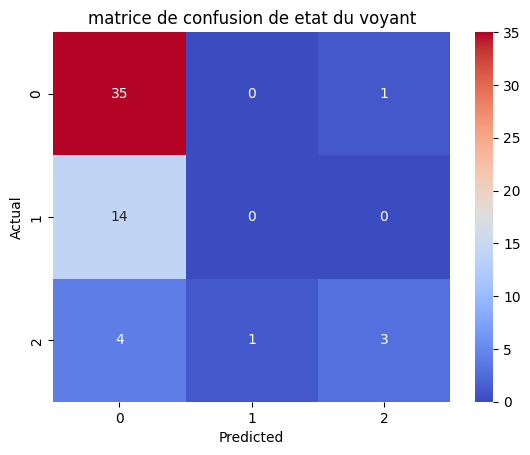

In [784]:
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='d')
plt.title('matrice de confusion de etat du voyant')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [785]:
pivot_df['predict_etat_voyant'] = pipeline.predict(X)

In [786]:
pivot_df['etat_voyant'].value_counts()

etat_voyant
0    158
1     45
2     26
3      1
Name: count, dtype: int64

In [787]:
pivot_df['predict_etat_voyant'].value_counts()

predict_etat_voyant
0    179
1     28
2     22
3      1
Name: count, dtype: int64

In [788]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [789]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['aero']),
                                                 ('num', StandardScaler(),
                                                  ['categorie_0', 'categorie_1',
                                                   'categorie_10',
                                                   'categorie_11',
                                                   'categorie_12',
                                                   'categorie_13',
                                                   'categorie_14',
                                                   'categorie_15',
                                                   'categorie_16',
                                                   'categorie_17',
                                                   'categorie_18',
                                                   'categorie_19',
                                                   'categorie_2',
                                                   'categorie_20',
                                                   'categorie_21',
                                                   'categorie_22',
                                                   'categorie_23',
                                                   'categorie_24',
                                                   'categorie_25',
                                                   'categorie_26',
                                                   'categorie_27',
                                                   'categorie_28',
                                                   'categorie_29',
                                                   'categorie_3',
                                                   'categorie_30',
                                                   'categorie_31',
                                                   'categorie_32',
                                                   'categorie_33',
                                                   'categorie_34',
                                                   'categorie_35', ...])])),
                ('classifier', RandomForestClassifier())])

In [790]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['aero']),
                                                 ('num', StandardScaler(),
                                                  ['categorie_0', 'categorie_1',
                                                   'categorie_10',
                                                   'categorie_11',
                                                   'categorie_12',
                                                   'categorie_13',
                                                   'categorie_14',
                                                   'categorie_15',
                                                   'categorie_16',
                                                   'categorie_17',
                                                   'categorie_18',
                                                   'categorie_19',
                                                   'categorie_2',
                                                   'categorie_20',
                                                   'categorie_21',
                                                   'categorie_22',
                                                   'categorie_23',
                                                   'categorie_24',
                                                   'categorie_25',
                                                   'categorie_26',
                                                   'categorie_27',
                                                   'categorie_28',
                                                   'categorie_29',
                                                   'categorie_3',
                                                   'categorie_30',
                                                   'categorie_31',
                                                   'categorie_32',
                                                   'categorie_33',
                                                   'categorie_34',
                                                   'categorie_35', ...])])),
                ('classifier', RandomForestClassifier())])

In [791]:
y_pred = pipeline.predict(X_test)

In [792]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      1.00      0.81        36
           1       0.00      0.00      0.00        14
           2       1.00      0.62      0.77         8

    accuracy                           0.71        58
   macro avg       0.56      0.54      0.53        58
weighted avg       0.56      0.71      0.61        58



C:\Users\uvlsp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\uvlsp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\uvlsp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

In [793]:
print('train score of random forest classifier is :', pipeline.score(X_train, y_train))
print('test score of random foreste classifier is : ', pipeline.score(X_test, y_test))

train score of random forest classifier is : 1.0
test score of random foreste classifier is :  0.7068965517241379


In [794]:
matrix = confusion_matrix(y_test, y_pred)

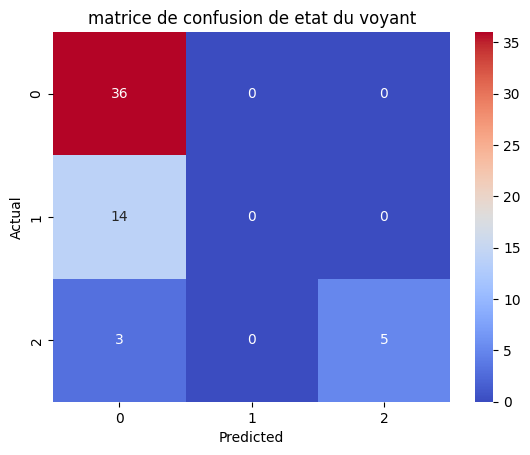

In [795]:
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='d')
plt.title('matrice de confusion de etat du voyant')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()